In [22]:
import pandas as pd

df = pd.DataFrame({
    "Year": list(range(2015, 2020)),
    "Observation": [123, 39, 78, 52, 110],
})

In [23]:
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=5, step=1)
Index(['Year', 'Observation'], dtype='object')


In [24]:
df.dtypes

Year           int64
Observation    int64
dtype: object

In [25]:
year_df = df.set_index("Year")
year_df

,Observation
Year,
2015,123
2016,39
2017,78
2018,52
2019,110


In [26]:
print(repr(pd.Timestamp("2020-01")))
print(repr(pd.Period("2020-01")))

Timestamp('2020-01-01 00:00:00')
Period('2020-01', 'M')


In [27]:
print(repr(pd.Timestamp("2020")))
print(repr(pd.Timestamp("2020-01-01 12:34")))
print(repr(pd.Period("2020-01-01")))
print(repr(pd.Period("2020-01-01", freq="M")))

Timestamp('2020-01-01 00:00:00')
Timestamp('2020-01-01 12:34:00')
Period('2020-01-01', 'D')
Period('2020-01', 'M')


In [28]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range("2020-01-01", "2020-01-02", freq="8h")
print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


In [29]:
print(ts_range.to_period())
print(ts_range.to_period(freq="D"))
print(ts_range.to_period(freq="W"))
print(ts_range.to_period().to_timestamp())

PeriodIndex(['2020-01-01 00:00', '2020-01-01 08:00', '2020-01-01 16:00',
             '2020-01-02 00:00'],
            dtype='period[8h]')
PeriodIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-02'], dtype='period[D]')
PeriodIndex(['2019-12-30/2020-01-05', '2019-12-30/2020-01-05',
             '2019-12-30/2020-01-05', '2019-12-30/2020-01-05'],
            dtype='period[W-SUN]')
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


In [30]:
print(ts_few.strftime("%m/%d/%Y"))
print(ts_range.to_period().strftime("%Y %b ~ %H:%M"))

Index(['01/01/2020', '01/02/2020', '01/03/2020'], dtype='object')
Index(['2020 Jan ~ 00:00', '2020 Jan ~ 08:00', '2020 Jan ~ 16:00',
       '2020 Jan ~ 00:00'],
      dtype='object')


In [31]:
df = pd.DataFrame({"ts": ts_few})
df = df.assign(
    period=df["ts"].dt.to_period(),
    yr=df["ts"].dt.year,
    str=df["ts"].dt.strftime("%A, %B %-d"),
).set_index("ts")
df

,period,yr,str
ts,,,
2020-01-01,2020-01-01,2020,2020-01-01 00:00:00
2020-01-02,2020-01-02,2020,2020-01-02 00:00:00
2020-01-03,2020-01-03,2020,2020-01-03 00:00:00


In [32]:
olympic_running = pd.read_csv("../data/olympic_running_unparsed.csv")
olympic_running.head(10)

,Year,Length,Sex,Time
0,1896,100,men,12.0
1,1900,100,men,11.0
2,1904,100,men,11.0
3,1908,100,men,10.8
4,1912,100,men,10.8
5,1916,100,men,NaN
6,1920,100,men,10.8
7,1924,100,men,10.6
8,1928,100,men,10.8
9,1932,100,men,10.3


In [33]:
print(olympic_running["Sex"].unique())


['men' 'women']


In [34]:
print(olympic_running[["Sex", "Length"]].drop_duplicates())

       Sex  Length
0      men     100
31   women     100
54     men     200
84   women     200
102    men     400
133  women     400
147    men     800
178  women     800
201    men    1500
232  women    1500
244    men    5000
271  women    5000
277    men   10000
304  women   10000


In [35]:
pbs = (
    pd.read_csv("../data/PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


In [36]:
a10 = pbs.loc[pbs["ATC2"] == "A10"]
a10

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,A,A10,89733,2092878.0
1525,1991-08-01,Concessional,Co-payments,A,A10,77101,1795733.0
1526,1991-09-01,Concessional,Co-payments,A,A10,76255,1777231.0
1527,1991-10-01,Concessional,Co-payments,A,A10,78681,1848507.0
1528,1991-11-01,Concessional,Co-payments,A,A10,70554,1686458.0
...,...,...,...,...,...,...,...
52339,2008-02-01,General,Safety net,A,A10,10869,530709.0
52340,2008-03-01,General,Safety net,A,A10,1119,51773.0
52341,2008-04-01,General,Safety net,A,A10,721,36289.0
52342,2008-05-01,General,Safety net,A,A10,1947,101233.0


In [37]:
a10 = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
)
a10

,Month,Concession,Type,Scripts,Cost
1524,1991-07-01,Concessional,Co-payments,89733,2092878.0
1525,1991-08-01,Concessional,Co-payments,77101,1795733.0
1526,1991-09-01,Concessional,Co-payments,76255,1777231.0
1527,1991-10-01,Concessional,Co-payments,78681,1848507.0
1528,1991-11-01,Concessional,Co-payments,70554,1686458.0
...,...,...,...,...,...
52339,2008-02-01,General,Safety net,10869,530709.0
52340,2008-03-01,General,Safety net,1119,51773.0
52341,2008-04-01,General,Safety net,721,36289.0
52342,2008-05-01,General,Safety net,1947,101233.0


In [38]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .rename(columns={"Cost": "TotalC"})
)
total_cost_df

,Month,TotalC
0,1991-07-01,3526591.0
1,1991-08-01,3180891.0
2,1991-09-01,3252221.0
3,1991-10-01,3611003.0
4,1991-11-01,3565869.0
...,...,...
199,2008-02-01,21654285.0
200,2008-03-01,18264945.0
201,2008-04-01,23107677.0
202,2008-05-01,22912510.0


In [39]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
)
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


In [40]:
prison = (
    pd.read_csv("../data/prison_population.csv", parse_dates=["Date"])
    .rename(columns={"Date": "Quarter"})
    .sort_values(by=["State", "Gender", "Legal", "Indigenous"])
)
prison

,Quarter,State,Gender,Legal,Indigenous,Count
0,2005-03-01,ACT,Female,Remanded,ATSI,0
64,2005-06-01,ACT,Female,Remanded,ATSI,1
128,2005-09-01,ACT,Female,Remanded,ATSI,0
192,2005-12-01,ACT,Female,Remanded,ATSI,0
256,2006-03-01,ACT,Female,Remanded,ATSI,1
...,...,...,...,...,...,...
2815,2015-12-01,WA,Male,Sentenced,Non-ATSI,2503
2879,2016-03-01,WA,Male,Sentenced,Non-ATSI,2488
2943,2016-06-01,WA,Male,Sentenced,Non-ATSI,2539
3007,2016-09-01,WA,Male,Sentenced,Non-ATSI,2608


In [41]:
total_cost_df.to_csv("../data/total_cost_df.csv", index=False)

In [50]:
import pandas as pd
from fpppy.utils import plot_series

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


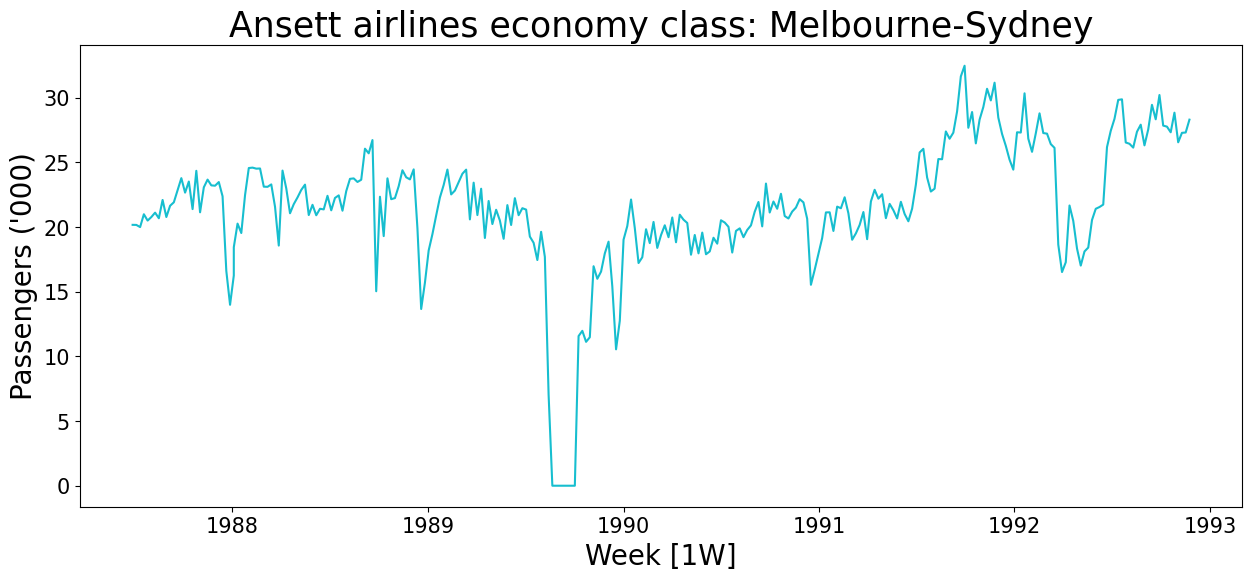

In [51]:
melsyd_economy = (
    pd.read_csv("../data/ansett.csv", parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)
plot_series(
    df=melsyd_economy, id_col="unique_id", time_col="ds", target_col="y",
    xlabel="Week [1W]", ylabel="Passengers ('000)",
    title="Ansett airlines economy class: Melbourne-Sydney")

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


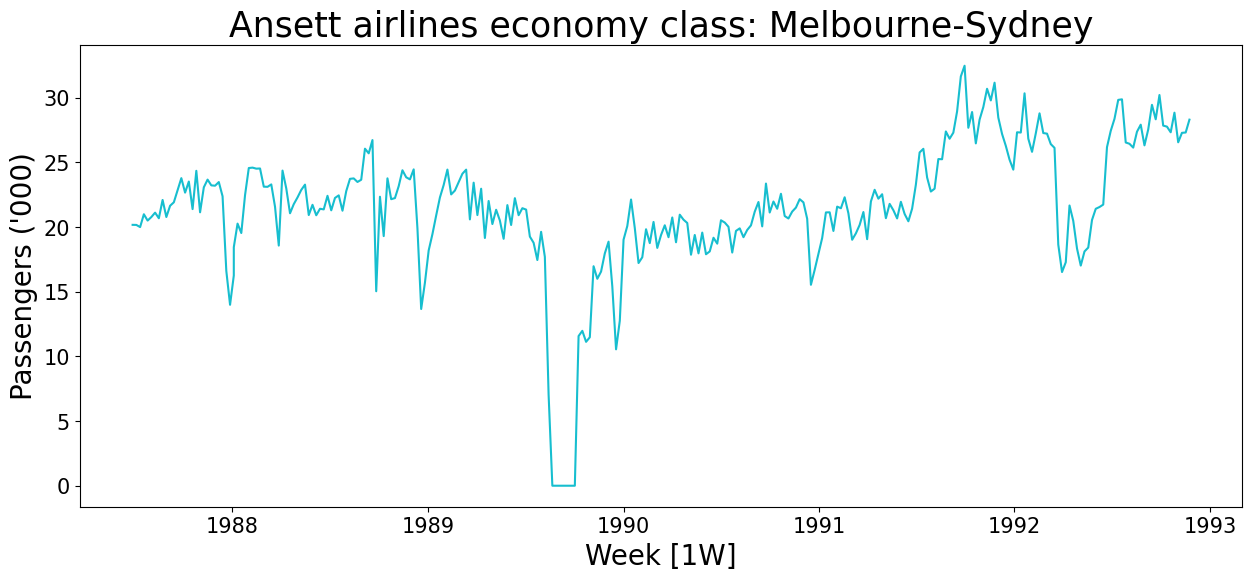

In [52]:
plot_series(melsyd_economy,
    xlabel="Week [1W]", ylabel="Passengers ('000)",
    title="Ansett airlines economy class: Melbourne-Sydney")

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


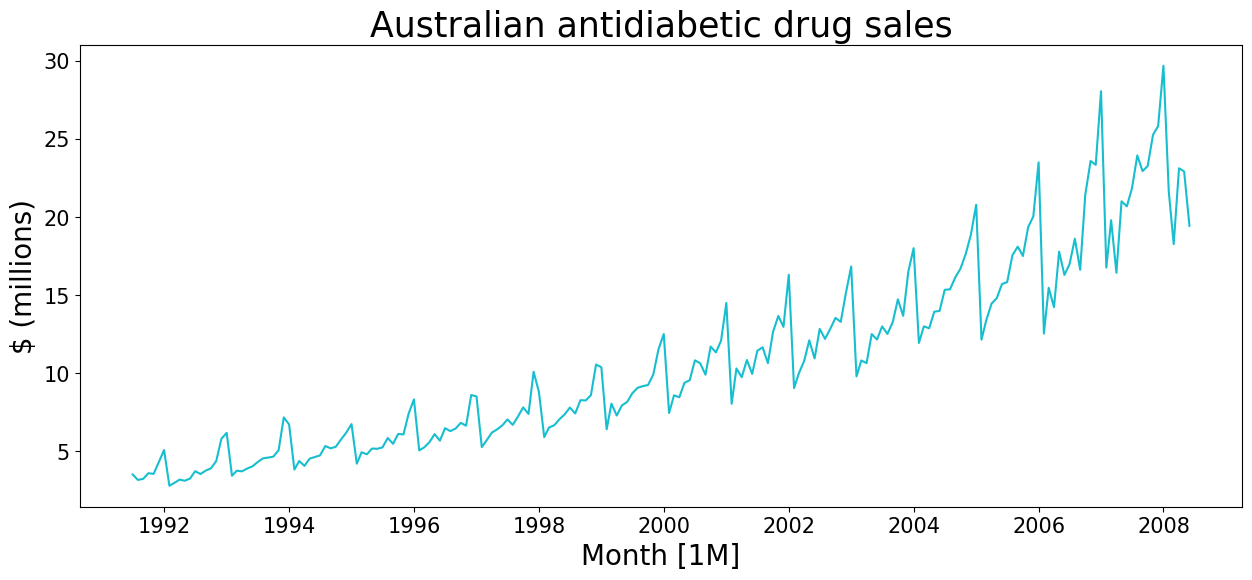

In [49]:
plot_series(total_cost_df.assign(unique_id="total_cost"),
    time_col="Month", target_col="Cost",
    xlabel="Month [1M]", ylabel="$ (millions)",
    title="Australian antidiabetic drug sales")

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\18820708.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


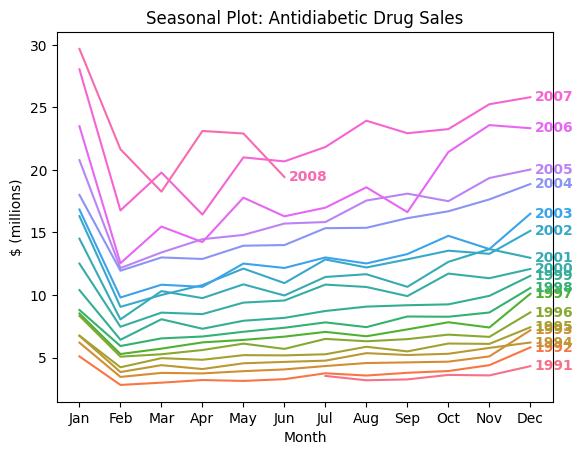

In [61]:
df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=10, weight="bold", color=color)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\1464600363.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


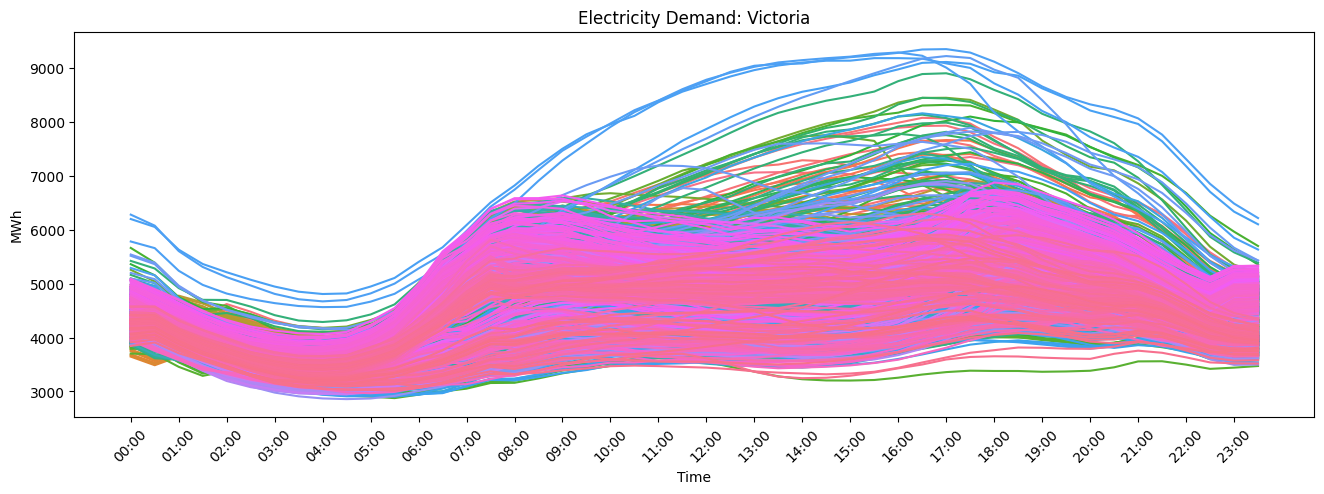

In [63]:
vic_elec_df = pd.read_csv("../data/vic_elec.csv", parse_dates=["ds"])
vic_elec_demand = vic_elec_df[vic_elec_df["unique_id"] == "Demand"]
df = vic_elec_demand.assign(
    hour_minute=lambda x: x["ds"].dt.strftime("%H:%M"),
    day=lambda x: x["ds"].dt.date,
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=df, x="hour_minute", y="y",
    hue="day", palette="husl", legend=False, ax=ax)
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
unique_ticks = df["hour_minute"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\4161809748.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


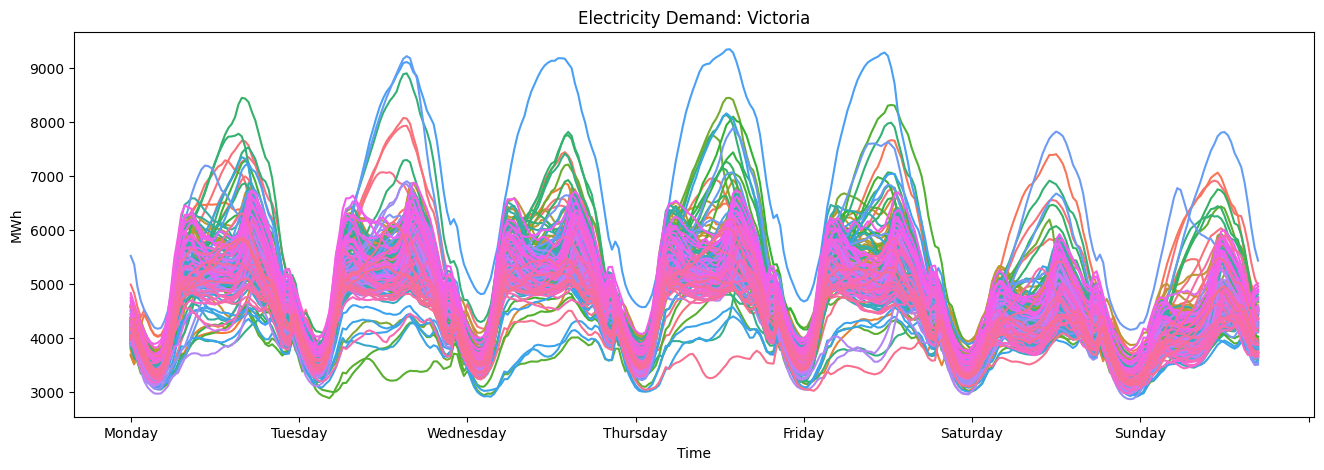

In [65]:
df = (
    vic_elec_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week=lambda x: x["ds"].dt.day_name(),
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots(figsize=(16, 5))
for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",
        ax=ax, color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\431423711.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


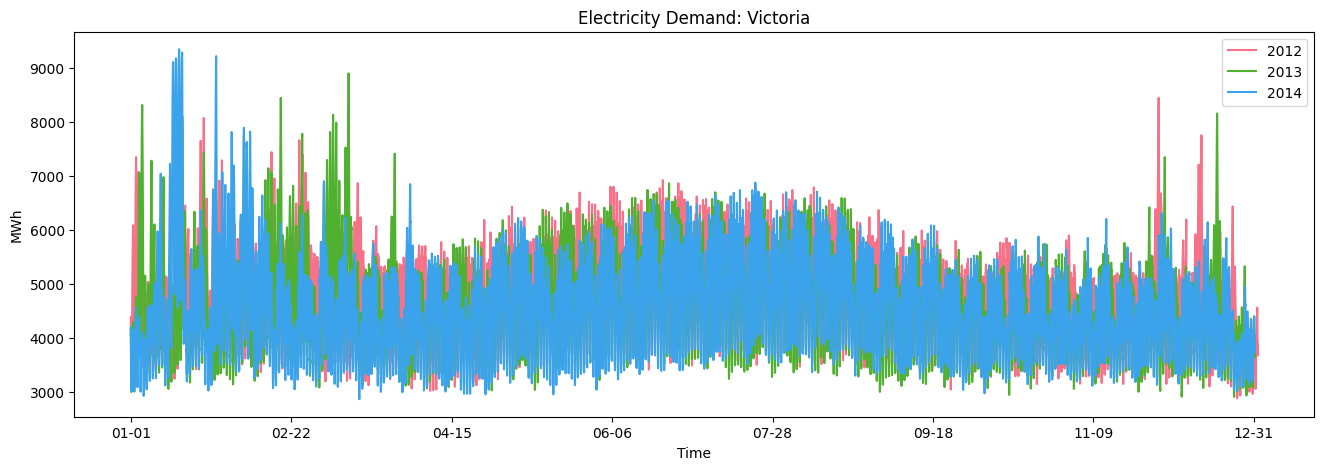

In [67]:
df = vic_elec_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)

palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots(figsize=(16, 5))
for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax,
        label=str(year), color=palette[i_year])
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\3576046290.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


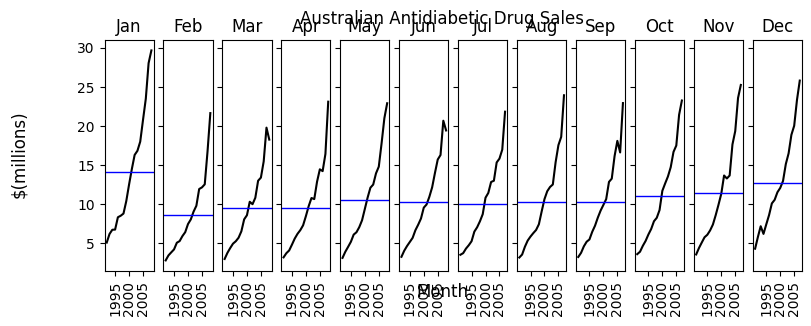

In [68]:
df = total_cost_df.assign(
    year=total_cost_df["Month"].dt.year,
    month_name=total_cost_df["Month"].dt.month_name(),
    month_idx=total_cost_df["Month"].dt.month,
)

fig, axes = plt.subplots(1, 12, figsize=(9, 3), sharey=True)
for ax, ((_, month_name), month_df) in zip(
        axes, df.groupby(["month_idx", "month_name"])):
    mean_cost = month_df["Cost"].mean()
    ax.plot(month_df["year"], month_df["Cost"], color="k")
    ax.axhline(mean_cost, color="b", linewidth=1)
    ax.set(title=month_name[:3], xlabel="")
    ax.tick_params(axis="x", rotation=90)

fig.suptitle("Australian Antidiabetic Drug Sales")
fig.supxlabel("Month")
fig.supylabel("$(millions)")
fig.show()

In [69]:
tourism = pd.read_csv("../data/tourism.csv", parse_dates=["ds"])
trips = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .groupby(["State", "ds"], as_index=False)
    .agg({"y": "sum"})
)
trips

,State,ds,y
0,ACT,1998-01-01,196.218550
1,ACT,1998-04-01,126.770597
2,ACT,1998-07-01,110.679645
3,ACT,1998-10-01,170.472206
4,ACT,1999-01-01,107.779245
...,...,...,...
635,Western Australia,2016-10-01,982.752589
636,Western Australia,2017-01-01,1134.352019
637,Western Australia,2017-04-01,997.852225
638,Western Australia,2017-07-01,879.988533


C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\3888130340.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


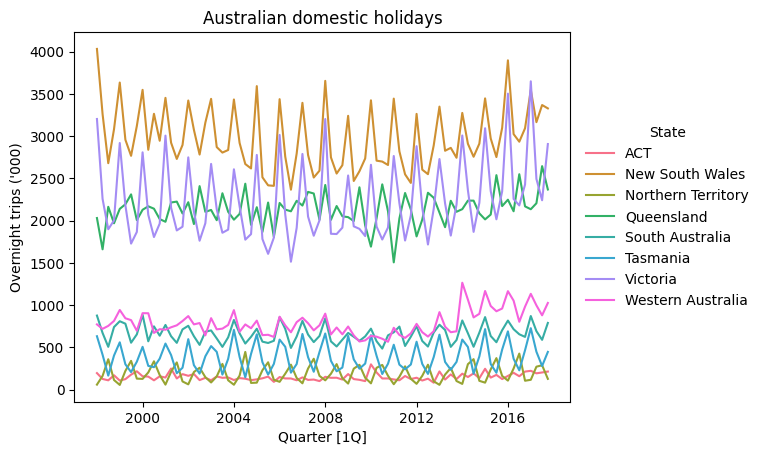

In [70]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", trips["State"].nunique())
sns.lineplot(data=trips, x="ds", y="y", hue="State", palette=palette)
ax.set(
    title="Australian domestic holidays",
    ylabel="Overnight trips ('000)",
    xlabel="Quarter [1Q]",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="State")
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\3514072415.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


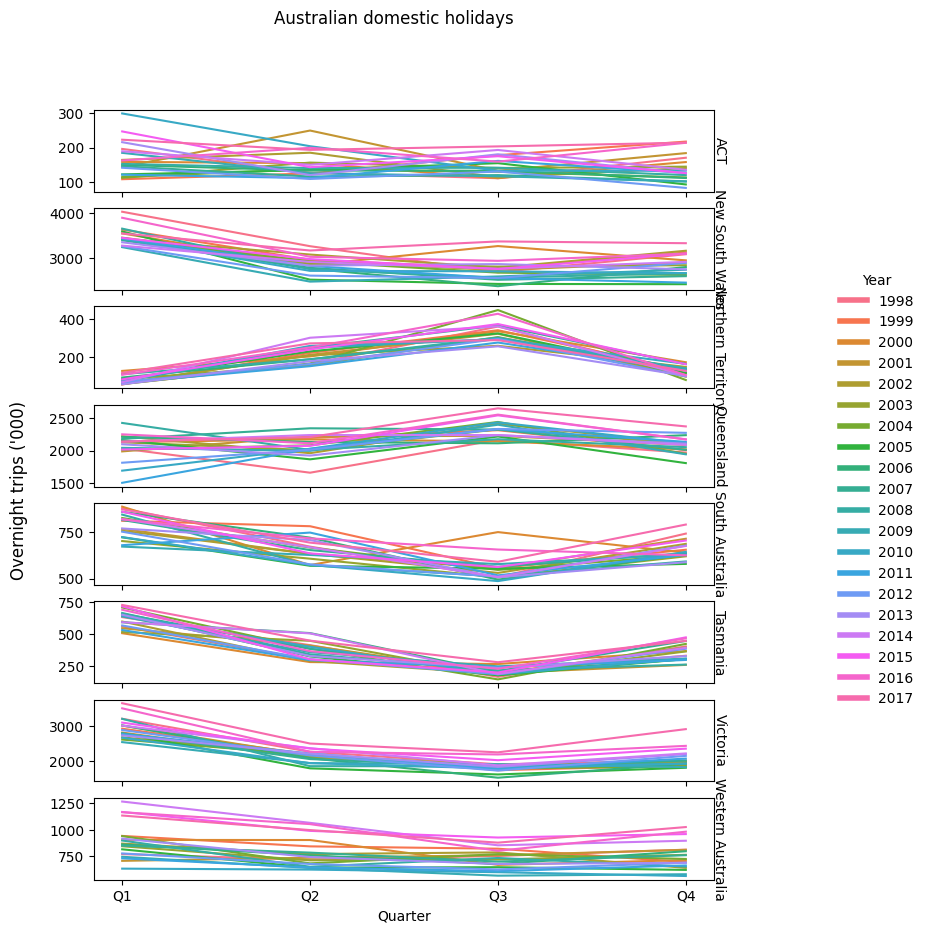

In [71]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)
num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig, axes = plt.subplots(num_states, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, df.groupby("State")):
    sns.lineplot(data=state_df, x="Quarter", y="y",
        hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,
        size="medium", transform=ax.transAxes)
handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)
fig.legend(handles, labels, title="Year", loc="center left",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.suptitle("Australian domestic holidays")
fig.supylabel("Overnight trips ('000)")
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\4083804369.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


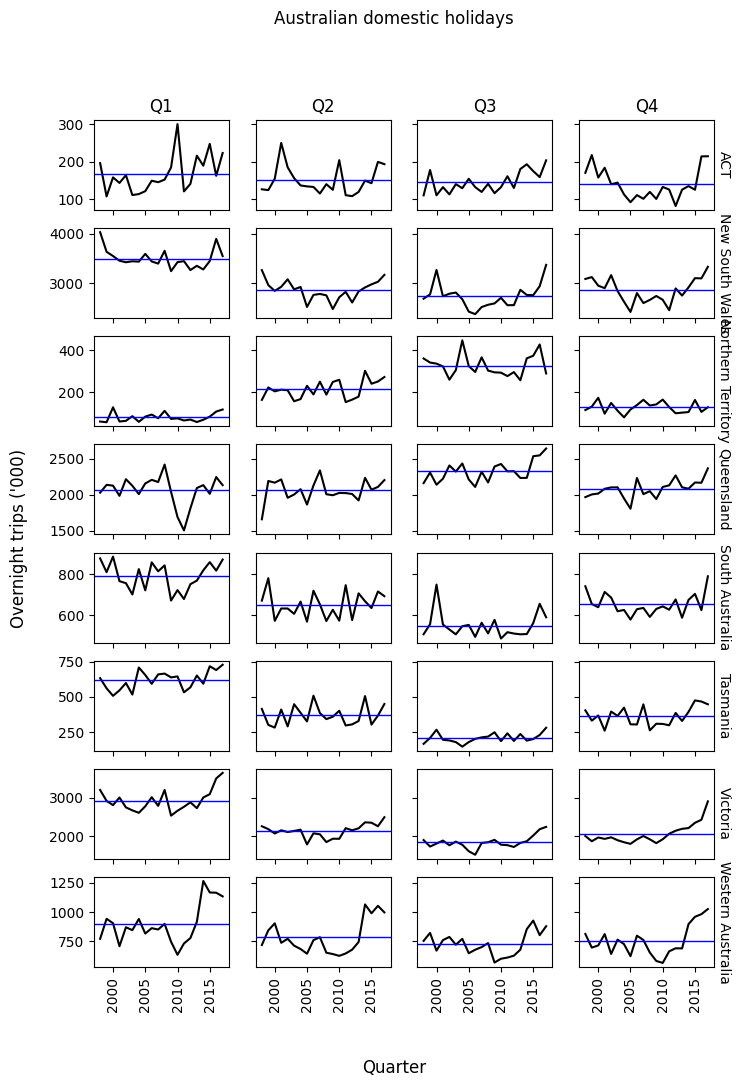

In [72]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


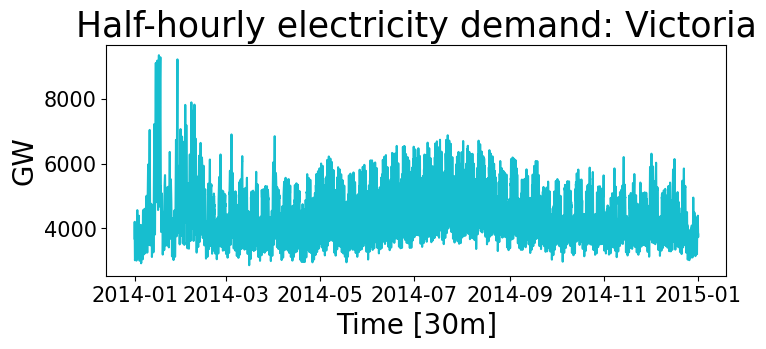

In [73]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(vic_elec_df, ids=["Demand"], ax=ax,
    max_insample_length=2 * 24 * 365,
    xlabel="Time [30m]", ylabel="GW",
    title="Half-hourly electricity demand: Victoria")

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


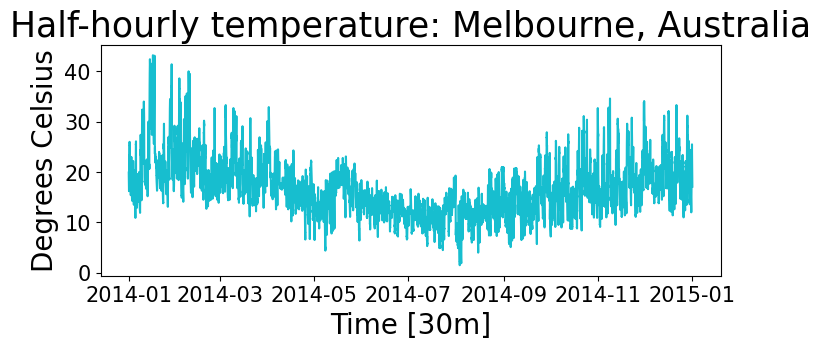

In [74]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(vic_elec_df, ids=["Temperature"], ax=ax,
    max_insample_length=2 * 24 * 365,
    xlabel="Time [30m]", ylabel="Degrees Celsius",
    title="Half-hourly temperature: Melbourne, Australia")

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\1756698181.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


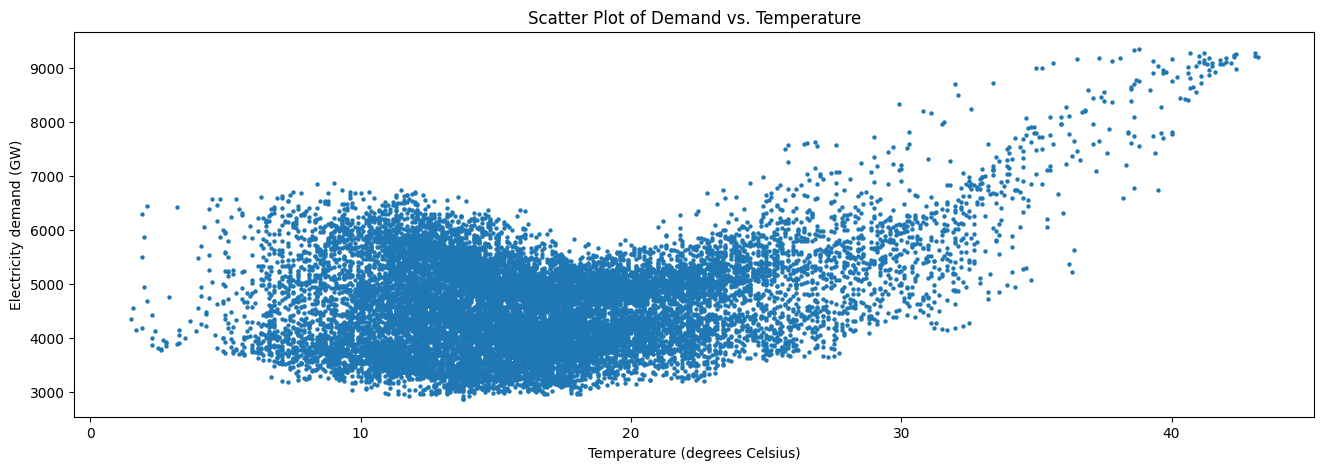

In [76]:
elec_2014 = (
    vic_elec_df.loc[lambda x: x["ds"].dt.year == 2014]
    .pivot(index="ds", columns="unique_id", values="y")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(16, 5))
sns.scatterplot(data=elec_2014, x="Temperature", y="Demand",
    ax=ax, linewidth=0, s=10, legend=False)
ax.set(
    title="Scatter Plot of Demand vs. Temperature",
    xlabel="Temperature (degrees Celsius)",
    ylabel="Electricity demand (GW)",
)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\2632841489.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


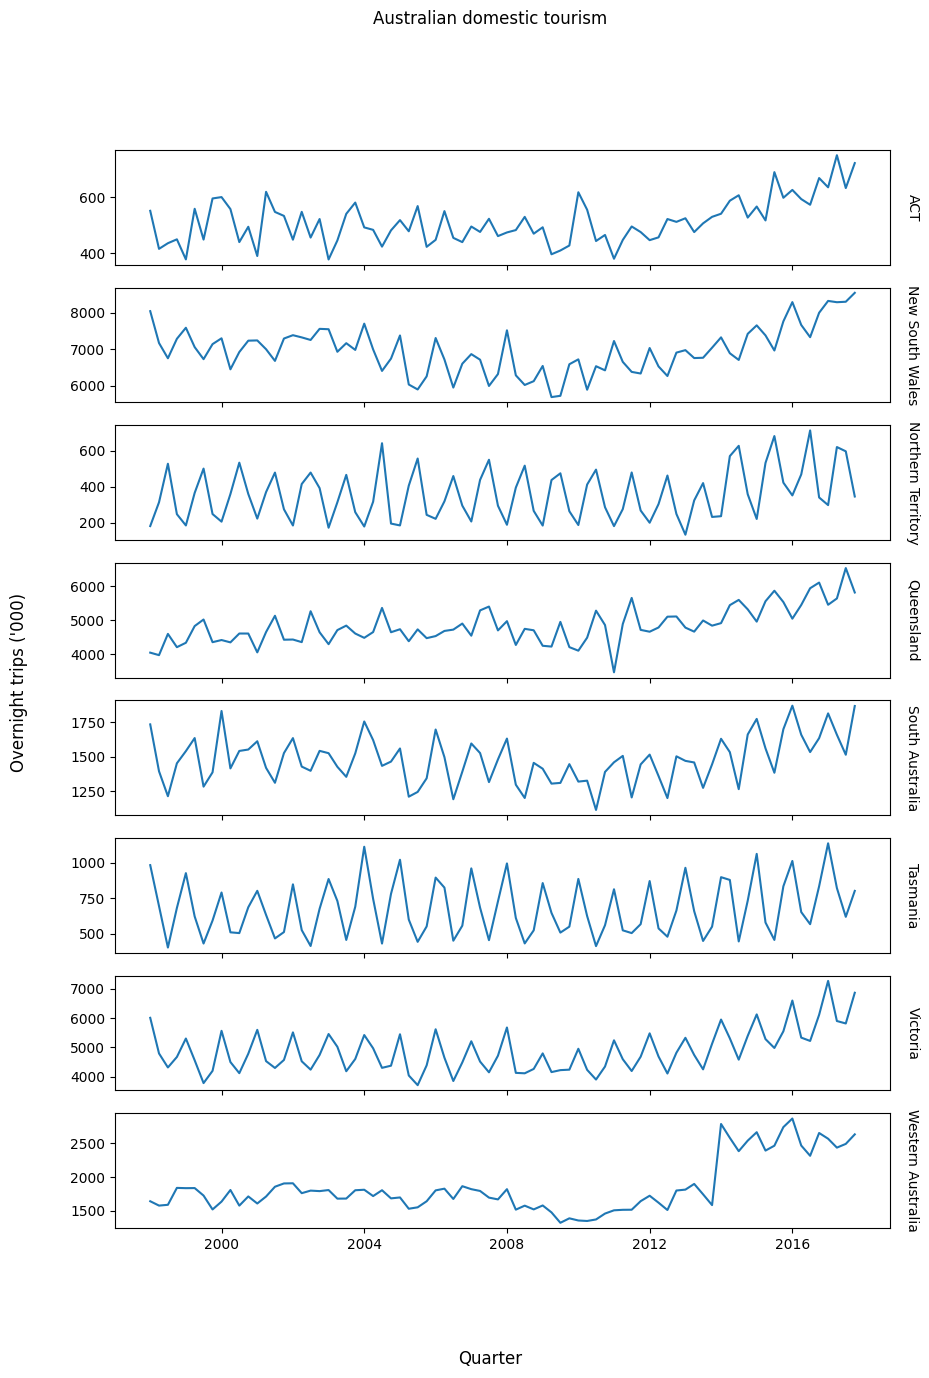

In [78]:
visitors = tourism.groupby(["State", "ds"], as_index=False)["y"].sum()
num_states = visitors["State"].nunique()
fig, axes = plt.subplots(num_states, 1, sharex=True, figsize=(10, 14))
for ax, (state, state_df) in zip(axes, visitors.groupby("State")):
    ax.plot(state_df["ds"], state_df["y"])
    ax.text(1.02, 0.5, state, va="center", ha="left",
        rotation=270, transform=ax.transAxes)
fig.suptitle("Australian domestic tourism")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

In [80]:
from scipy.stats import pearsonr

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\2285077027.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


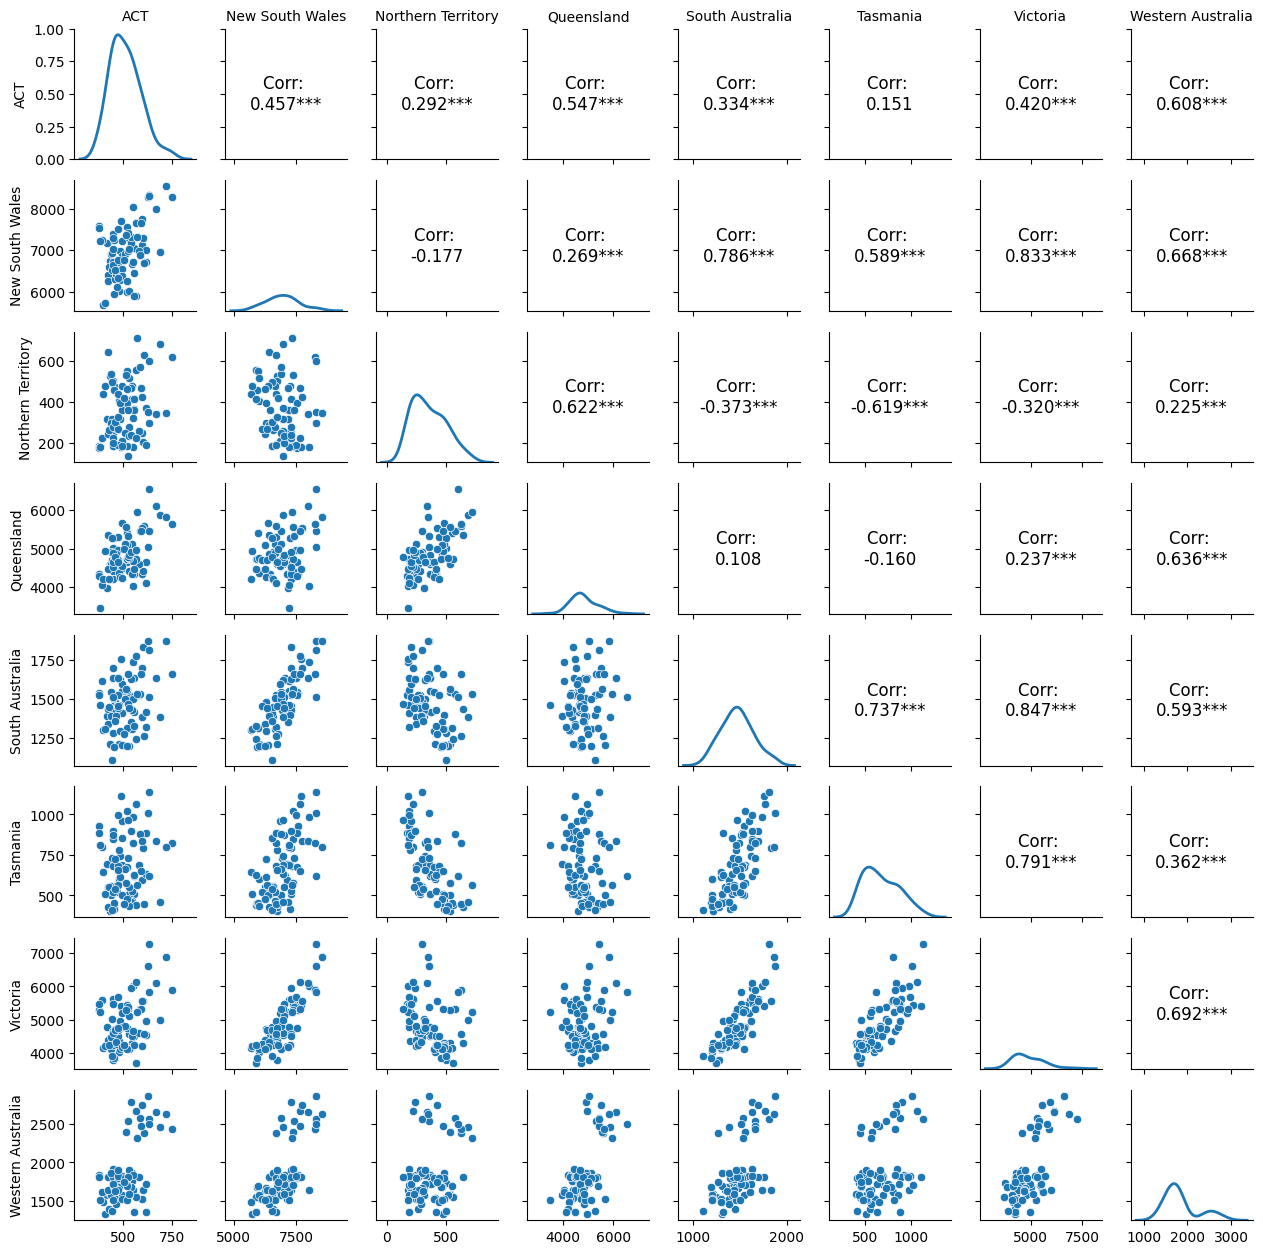

In [81]:
df = visitors.pivot(index="ds", columns="State", values="y")

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: \n{r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center", fontsize=12)

g = sns.PairGrid(df, height=1.6)
g.map_lower(sns.scatterplot)
g.map_upper(corrfunc)
g.map_diag(sns.kdeplot, lw=2)
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size="medium")
fig.show()

Text(0.02, 0.5, 'Beer')

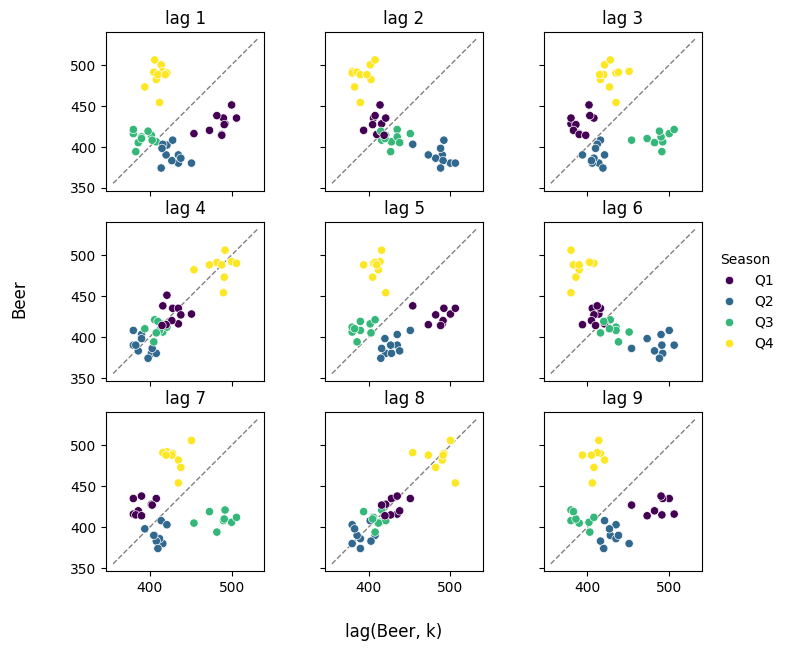

In [82]:
beer = (
    pd.read_csv("../data/aus_production.csv", parse_dates=["ds"])
    [["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "2000"]
    .assign(Season=lambda x: "Q" + x["ds"].dt.quarter.astype("string"))
    .rename(columns={"Beer": "y"})
)
lims = .95 * beer["y"].min(), 1.05 * beer["y"].max()

cmap = plt.get_cmap("viridis")
colors = {
    season: cmap(i / 3)
    for i, season in enumerate(beer["Season"].unique())
}

fig, axes = plt.subplots(3, 3, figsize=(8, 7), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    df = beer.assign(lag=beer["y"].shift(lag))

    sns.scatterplot(data=df, x="lag", y="y", hue="Season",
        palette=colors, ax=ax)
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag}", xlabel="", ylabel="", aspect="equal")
    ax.get_legend().remove()
axes[1, -1].legend(loc="center left", title="Season",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.supxlabel("lag(Beer, k)")
fig.supylabel("Beer")

In [84]:
import statsmodels.api as sm

In [85]:
acf = sm.tsa.acf(beer["y"], nlags=9, fft=False, bartlett_confint=False)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")
acf_df[1:]

,ACF
lag,
1,-0.052981
2,-0.758175
3,-0.026234
4,0.802205
5,-0.077471
6,-0.657451
7,0.001195
8,0.707254
9,-0.088756


In [87]:
from statsmodels.graphics.tsaplots import plot_acf

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\970896520.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


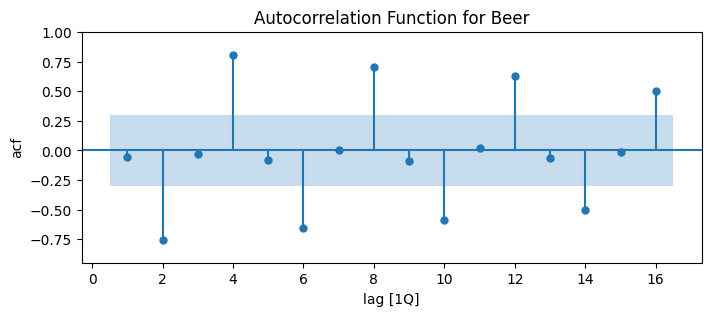

In [88]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(beer["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for Beer",
    xlabel="lag [1Q]", ylabel="acf",
)
fig.show()

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\1131514431.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


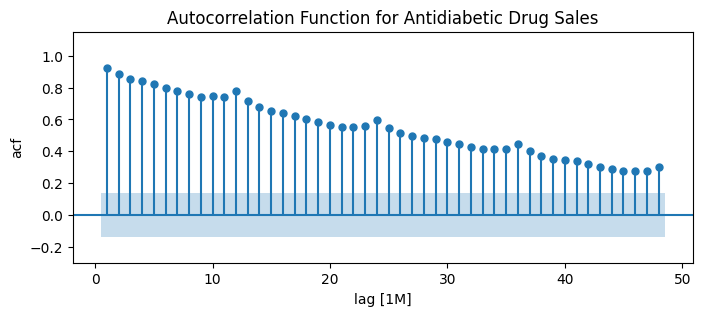

In [89]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(total_cost_df["Cost"], lags=48, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for Antidiabetic Drug Sales",
    xlabel="lag [1M]", ylabel="acf", ylim=(-0.3, None),
)
fig.show()

In [91]:
import numpy as np

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


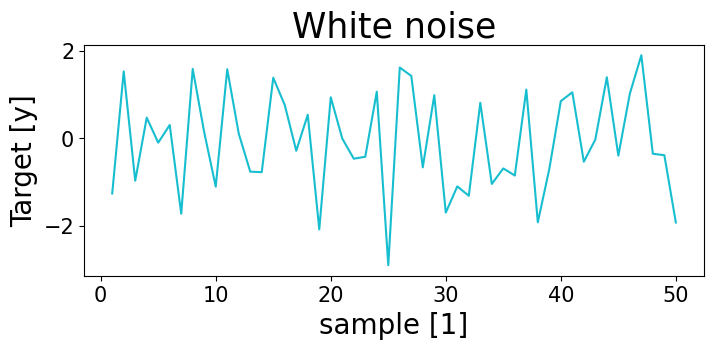

In [92]:
random = np.random.RandomState(30)
wn = pd.DataFrame({
    "y": random.normal(0, 1, 50),
    "ds": np.arange(1, 51),
    "unique_id": "wn",
})
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(wn, target_col="y",
    xlabel="sample [1]", title="White noise", ax=ax)

C:\Users\vanma\AppData\Local\Temp\ipykernel_17836\482179086.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


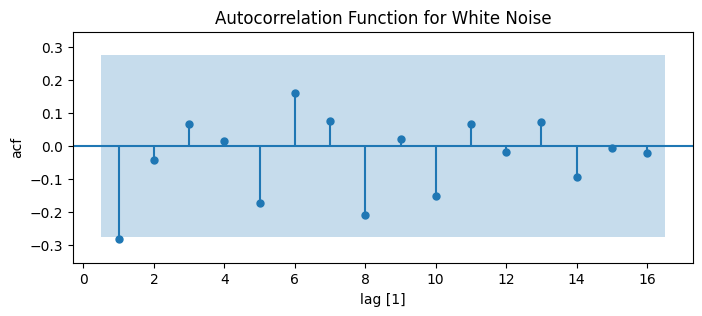

In [93]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(wn["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for White Noise",
    xlabel="lag [1]", ylabel="acf",
)
fig.show()

## A partir daqui são atividades de validação do conhecimento

Explore as seguintes quatro séries temporais: Bricksde aus_production, Lynxde pelt, GOOG_Closede gafa_stock, Demandde vic_elec.

Utilize .info()para obter informações sobre os dados em cada série.
Qual é o intervalo de tempo de cada série?
Utilize esta ferramenta plot_series()para gerar um gráfico temporal de cada série.
Para o último gráfico, modifique os rótulos dos eixos e o título.

In [104]:
pd.read_csv("../data/aus_production.csv", parse_dates=["ds"]).columns


Index(['ds', 'Beer', 'Tobacco', 'Bricks', 'Cement', 'Electricity', 'Gas'], dtype='object')

In [109]:
pelt = pd.read_csv("../data/pelt.csv", parse_dates=["ds"])
lynx = pelt.loc[pelt["unique_id"] == "lynx"].drop(columns=["unique_id"])
lynx.info()


<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, 91 to 181
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      91 non-null     datetime64[ns]
 1   y       91 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.1 KB


In [110]:
print(lynx["ds"].min(), lynx["ds"].max())

1845-01-01 00:00:00 1935-01-01 00:00:00


In [ ]:
gafa_stock = pd.read_csv("../data/gafa_stock.csv", parse_dates=["ds"])
gafa_stock["unique_id"].unique()  # vê quais séries existem

Index(['unique_id', 'ds', 'y'], dtype='object')

In [107]:
gafa_stock = pd.read_csv("../data/vic_elec.csv", parse_dates=["ds"])
gafa_stock["unique_id"].unique()  # vê quais séries existem

array(['Demand', 'Temperature'], dtype=object)